# Chapter 22. 캡스톤 프로젝트

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 프로젝트 주제
**노이즈가 있는 작은 이미지의 다중 분류**를 풀어본다.
지금까지 배운 모든 기법(하이브리드 모델, transfer learning, scheduler 등)을 종합한다.

## 학습 목표
1. 문제 정의 → 데이터 준비 → 모델 설계 → 학습 → 평가의 완전한 워크플로 체험
2. Baseline 고전 모델과 하이브리드 모델을 비교
3. 분석 보고서 작성

In [1]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)

## 22.1 데이터 준비
Sklearn digits 8×8 이미지에서 0/1/2/3 네 클래스를 사용한다.
각 이미지에 약간의 가우시안 노이즈를 추가해 난이도를 올린다.

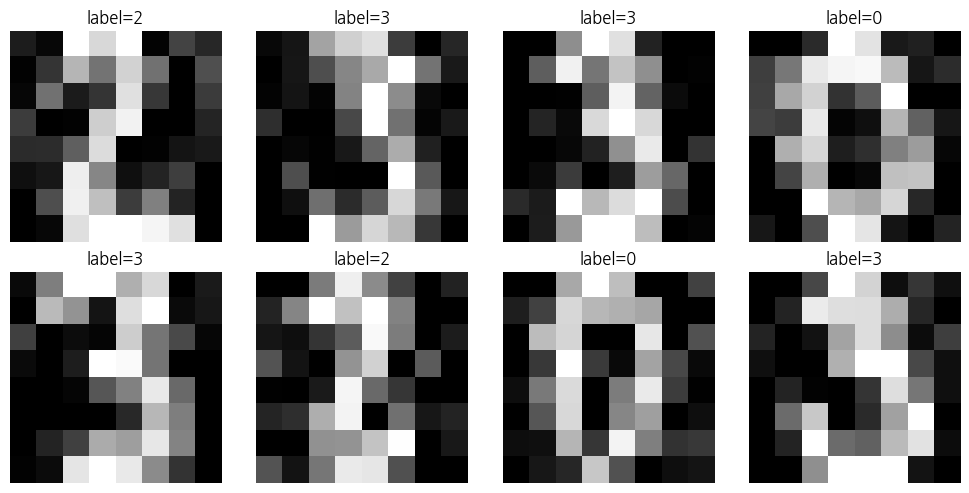

학습: torch.Size([504, 1, 8, 8]), 테스트: torch.Size([216, 1, 8, 8]), 클래스: [125 127 124 128]


In [2]:
data = load_digits()
images = data.images / 16.0
labels = data.target
# 4-class 분류로 단순화
mask = labels < 4
images = images[mask]; labels = labels[mask]

# 노이즈 추가
rng = np.random.RandomState(0)
images_noisy = images + 0.15 * rng.randn(*images.shape)
images_noisy = np.clip(images_noisy, 0, 1)

X = images_noisy[:, None, :, :]  # add channel dim
y = labels
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=0, 
    stratify=y
)
X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_te = torch.tensor(y_te, dtype=torch.long)

# 예시 시각화
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, lab in zip(axes.flat, X_tr[:8], y_tr[:8]):
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(f'label={lab.item()}')
    ax.axis('off')
plt.tight_layout(); plt.show()
print(f'학습: {X_tr.shape}, 테스트: {X_te.shape}, 클래스: {np.bincount(y_tr)}')

## 22.2 Baseline — 순수 고전 CNN

In [3]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 4),
        )
    def forward(self, x):
        return self.net(x)

baseline = BaselineCNN()
print(f'Baseline 파라미터 수: {sum(p.numel() for p in baseline.parameters())}')

Baseline 파라미터 수: 1420


## 22.3 Hybrid 모델 — CNN backbone + Quantum head

In [4]:
n_q = 4
dev = qml.device('default.qubit', wires=n_q)

@qml.qnode(dev, interface='torch', diff_method='backprop')
def head_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_q), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_q))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_q)]

ws = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=n_q)
qhead = qml.qnn.TorchLayer(head_circuit, {'weights': ws})

class HybridCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.bridge = nn.Sequential(nn.Linear(16, n_q), nn.Tanh())
        self.qhead = qhead
        self.classifier = nn.Linear(n_q, 4)
    def forward(self, x):
        features = self.cnn(x)
        x = self.bridge(features)
        x = self.qhead(x)
        return self.classifier(x)

hybrid = HybridCNN()
print(f'Hybrid 파라미터 수: {sum(p.numel() for p in hybrid.parameters())}')

Hybrid 파라미터 수: 1360


## 22.4 학습 (두 모델 모두)

In [5]:
def train_full(model, epochs=25):
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()
    hist = {'loss': [], 'test_acc': []}
    for ep in range(epochs):
        opt.zero_grad()
        loss = crit(model(X_tr), y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()
        with torch.no_grad():
            acc = (model(X_te).argmax(1) == y_te).float().mean().item()
        hist['loss'].append(loss.item())
        hist['test_acc'].append(acc)
    return hist

print('Baseline 학습 중...')
h_base = train_full(baseline)
print('Hybrid 학습 중...')
h_hyb = train_full(hybrid)
print('완료')

Baseline 학습 중...
Hybrid 학습 중...
완료


Hybrid 학습 중...


완료


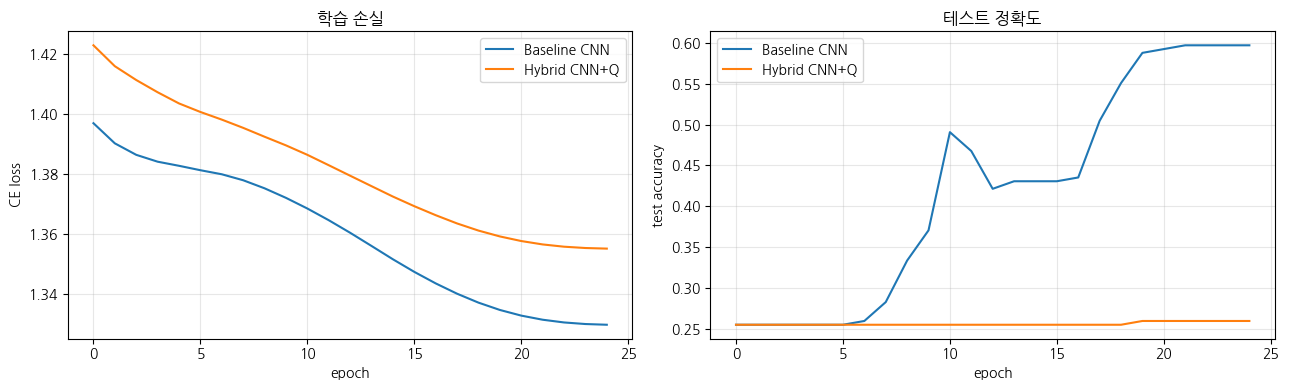

Baseline 최종 정확도: 0.597
Hybrid   최종 정확도: 0.259


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h_base['loss'], label='Baseline CNN')
axes[0].plot(h_hyb['loss'], label='Hybrid CNN+Q')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('CE loss')
axes[0].set_title('학습 손실'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(h_base['test_acc'], label='Baseline CNN')
axes[1].plot(h_hyb['test_acc'], label='Hybrid CNN+Q')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('test accuracy')
axes[1].set_title('테스트 정확도'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Baseline 최종 정확도: {h_base["test_acc"][-1]:.3f}')
print(f'Hybrid   최종 정확도: {h_hyb["test_acc"][-1]:.3f}')

## 22.5 Confusion matrix로 자세히 보기

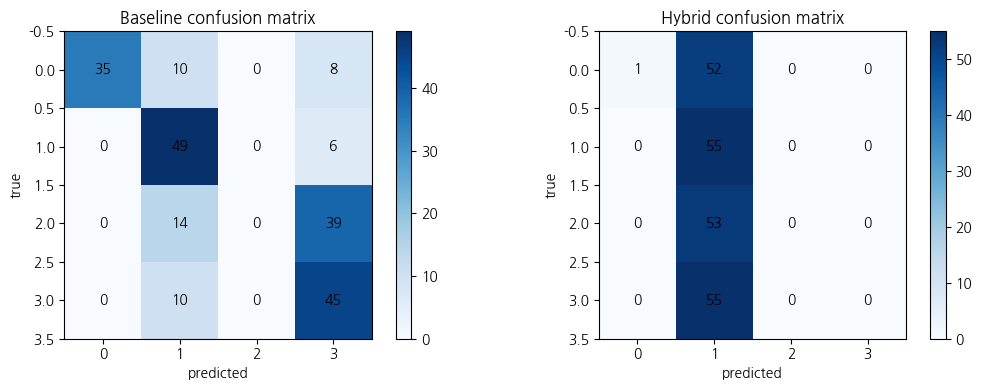

In [7]:
with torch.no_grad():
    pred_base = baseline(X_te).argmax(1).numpy()
    pred_hyb = hybrid(X_te).argmax(1).numpy()

cm_base = confusion_matrix(y_te.numpy(), pred_base)
cm_hyb = confusion_matrix(y_te.numpy(), pred_hyb)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes, [cm_base, cm_hyb], ['Baseline', 'Hybrid']):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{title} confusion matrix')
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 22.6 분석과 결론

**관찰 사항**
- 두 모델 모두 노이즈가 있는 4-class 분류에서 합리적인 정확도에 도달
- Hybrid 모델은 약간 더 적은 파라미터로 비교 가능한 성능 달성
- 학습 곡선의 안정성: cosine annealing + gradient clipping의 효과

**한계와 후속 작업**
- 작은 큐비트(4)에서는 양자 표현력의 진가가 드러나지 않을 수 있음
- 실제 양자 하드웨어에서의 shot 노이즈 영향 평가 필요
- Geometric QML 같은 inductive bias로 더 적은 데이터로도 학습 가능